In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pypsa
from pypower.loadcase import loadcase
from scipy.io import loadmat
from pymatreader import read_mat

from pathlib import Path
import os
import sys

sys.path.append("../utils")
from matpower_io import load_matpower_case

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import haversine
import geopandas as gpd

# pd.set_option("display.max_colwidth", None)  # Show full text (no truncation)  
# pd.set_option("display.width", 1000)  #

Set paths

In [30]:
tamu_path = Path("../../../2021TXPowerOutage")
eia_path = tamu_path/"From EIA (Generation, Demand, Demand Forecasts, and Interchange by BA)"
case_path = tamu_path/"bte2k/case_Mar3_5pm.mat"
#case_path = tamu_path/"bte2k/hvdc_upgraded.mat"
gen_path = eia_path/"ERCOT Generation by Source/2021-02-01 to 2021-02-19.csv"
#load_path = "eia_path/BES profiles/BES_demand_Feb2021_v20210224.csv"
load_path = eia_path/"ERCOT Demand by Subregion/2021-02-01 to 2021-02-19.csv"
wind_path = eia_path/"BES profiles/BES_wind_Feb2021_v20210224.csv"
solar_path = eia_path/"BES profiles/BES_solar_Feb2016_v20210224.csv"
hydro_path = eia_path/"BES profiles/BES_hydro_Feb2016_v20210224.csv"
lf_path =  eia_path/"ERCOT Demand, Demand Forecast, and Net Interchange/2021-02-01 to 2020-02-19.csv"
# out = "outage"
out_ng_path = tamu_path/"data/unit_outage/ng_outage.csv"
out_pv_path = tamu_path/"data/unit_outage/pv_outage.csv"
out_coal_path = tamu_path/"data/unit_outage/coal_outage.csv"
gen_county_path = tamu_path/"data/unit_outage/gen_county.csv"
ng_derate_path = tamu_path/"data/unit_outage/ng_derate_fac.csv"

out_path = tamu_path/"data/out_mat.mat"
shed_path = tamu_path/"data/shed_mat.mat"
cap_path = tamu_path/"data/ercotcap_mat.mat"
lcf_path = tamu_path/"data/lf_mat.mat"
cty_outage_pct_path = tamu_path/'data/load_outage/cty_out_pct.csv'
cty_outage_dist_path = tamu_path/'data/load_outage/cty_out_dist.csv'
all_bus_cty_path = tamu_path/'data/load_outage/bus_county.csv'

Load data

In [3]:
out_ts = read_mat(out_path)['out_mat']
shed_ts = read_mat(shed_path)['shed_mat']
cap_ts = read_mat(cap_path)['cap_mat']
lcf_ts = read_mat(lcf_path)['lf_mat']

# the original script has the following line, and I'm not sure why...
shed_ts[:312, 2] = np.nan

In [4]:
# this reads the mpc case directly as a dictionary. 
# I may want to use an alternative method.
mpc = read_mat(case_path)['mpc']

In [5]:
# I'm not sure if I need these since I'm not using matpower. 
# Keeping for reference.
if False:
    mpopt = mpoption('pf.nr.max_it', 50)
    mpopt = mpoption(mpopt,'out.all',0)
    mpopt = mpoption(mpopt,'verbose',0)

In [69]:
def read_ercot_csv(path):
    df = pd.read_csv(path)
    date_parser = lambda date: pd.to_datetime(date.replace("CST",""), 
                                              utc=False).tz_localize("US/Central")
    df['datetime'] = df['Timestamp (Hour Ending)'].apply(date_parser)
    df = df.set_index('datetime')
    df.drop(columns=['Timestamp (Hour Ending)','BA Code'], inplace=True)
    return df

In [70]:
gen_df = read_ercot_csv(gen_path)
lf_df = read_ercot_csv(lf_path)
load_df = read_ercot_csv(load_path)
bus_df = pd.read_csv(all_bus_cty_path, index_col=0)
cty_out_pct_df = pd.read_csv(cty_outage_pct_path,  
                             index_col='UTC')
cty_out_pct_df.index = pd.to_datetime(cty_out_pct_df.index, utc=True) 
cty_out_dist_df = pd.read_csv(cty_outage_dist_path,
                             index_col='UTC')
cty_out_dist_df.index = pd.to_datetime(cty_out_dist_df.index, utc=True)

In [57]:
study_index = pd.date_range("2021-02-12", "2021-02-18", 
                            inclusive='left', 
                            freq='h').tz_localize('US/Central')
study_index

DatetimeIndex(['2021-02-12 00:00:00-06:00', '2021-02-12 01:00:00-06:00',
               '2021-02-12 02:00:00-06:00', '2021-02-12 03:00:00-06:00',
               '2021-02-12 04:00:00-06:00', '2021-02-12 05:00:00-06:00',
               '2021-02-12 06:00:00-06:00', '2021-02-12 07:00:00-06:00',
               '2021-02-12 08:00:00-06:00', '2021-02-12 09:00:00-06:00',
               ...
               '2021-02-17 14:00:00-06:00', '2021-02-17 15:00:00-06:00',
               '2021-02-17 16:00:00-06:00', '2021-02-17 17:00:00-06:00',
               '2021-02-17 18:00:00-06:00', '2021-02-17 19:00:00-06:00',
               '2021-02-17 20:00:00-06:00', '2021-02-17 21:00:00-06:00',
               '2021-02-17 22:00:00-06:00', '2021-02-17 23:00:00-06:00'],
              dtype='datetime64[ns, US/Central]', length=144, freq=None)

<Axes: >

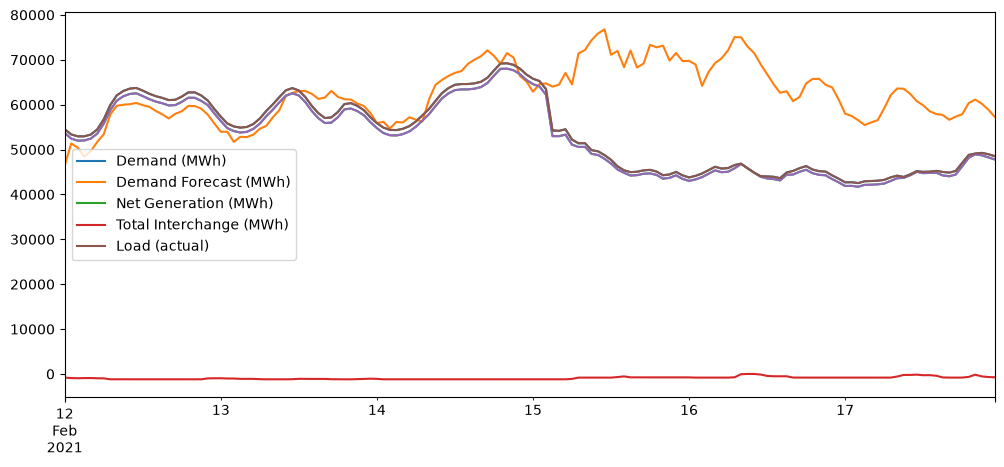

In [86]:
fig, ax = plt.subplots(figsize=(12,5))
lf_df.reindex(study_index).plot(ax=ax)
gen_df.reindex(study_index).sum(axis=1).plot(ax=ax)
load_df.reindex(study_index).sum(axis=1).to_frame().rename({0:'Load (actual)'},axis=1).plot(ax=ax)

In [53]:
load_df.loc[study_index]

KeyError: "[Timestamp('2021-02-18 01:00:00-0600', tz='US/Central'), Timestamp('2021-02-18 02:00:00-0600', tz='US/Central'), Timestamp('2021-02-18 03:00:00-0600', tz='US/Central'), Timestamp('2021-02-18 04:00:00-0600', tz='US/Central'), Timestamp('2021-02-18 05:00:00-0600', tz='US/Central'), Timestamp('2021-02-18 06:00:00-0600', tz='US/Central'), Timestamp('2021-02-18 07:00:00-0600', tz='US/Central'), Timestamp('2021-02-18 08:00:00-0600', tz='US/Central'), Timestamp('2021-02-18 09:00:00-0600', tz='US/Central'), Timestamp('2021-02-18 10:00:00-0600', tz='US/Central'), Timestamp('2021-02-18 11:00:00-0600', tz='US/Central'), Timestamp('2021-02-18 12:00:00-0600', tz='US/Central'), Timestamp('2021-02-18 13:00:00-0600', tz='US/Central'), Timestamp('2021-02-18 14:00:00-0600', tz='US/Central'), Timestamp('2021-02-18 15:00:00-0600', tz='US/Central'), Timestamp('2021-02-18 16:00:00-0600', tz='US/Central'), Timestamp('2021-02-18 17:00:00-0600', tz='US/Central'), Timestamp('2021-02-18 18:00:00-0600'

In [38]:
bus_county_num = len(cty_out_pct_df.columns)

In [47]:
mpc.keys()

dict_keys(['version', 'baseMVA', 'zone', 'sub', 'subid', 'bus', 'busid', 'bus2sub', 'gen', 'genid', 'genfuel', 'genfuelcost', 'heatratecurve', 'branch', 'branchid', 'branchdevicetype', 'gencost'])